# Importando as Bibliotecas e Tabelas

In [2]:
import pandas as pd
from pathlib import Path

In [3]:
# Caminho base dos dados
DATA = Path("../../data")

# Função para carregar todos os CSVs de um prefixo
def load_csvs(prefix):
    files = sorted(DATA.glob(f"{prefix}-*.csv"))
    frames = []
    for file in files:
        df = pd.read_csv(file, sep=";", quotechar='"', low_memory=False)
        df["ano"] = int(file.stem.split("-")[-1])  # salva o ano como coluna
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

# Carregando os dados
votacoes         = load_csvs("voting/votacoes")
votos            = load_csvs("voting/votes/votacoesVotos")
votacoes_props   = load_csvs("voting/proposition/votacoesProposicoes")
temas_propos     = load_csvs("propositions/proposicoesTemas")
orientacoes      = load_csvs("voting/orientations/votacoesOrientacoes")
autores          = load_csvs("authors/proposicoesAutores")

deputados        = pd.read_csv("../../data/deputies/deputados.csv", sep=";", quotechar='"', low_memory=False)
legislaturas     = pd.read_csv("../../data/extra/legislaturas.csv", sep=";", quotechar='"', low_memory=False)
orgaos           = pd.read_csv("../../data/extra/orgaos.csv", sep=";", quotechar='"', low_memory=False)
frentes_deputados = pd.read_csv("../../data/fronts/frentesDeputados.csv", sep=";", quotechar='"', low_memory=False)

# Análise da tabela de Votações

In [4]:
votacoes.columns

Index(['id', 'uri', 'data', 'dataHoraRegistro', 'idOrgao', 'uriOrgao',
       'siglaOrgao', 'idEvento', 'uriEvento', 'aprovacao', 'votosSim',
       'votosNao', 'votosOutros', 'descricao',
       'ultimaAberturaVotacao_dataHoraRegistro',
       'ultimaAberturaVotacao_descricao',
       'ultimaApresentacaoProposicao_dataHoraRegistro',
       'ultimaApresentacaoProposicao_descricao',
       'ultimaApresentacaoProposicao_idProposicao',
       'ultimaApresentacaoProposicao_uriProposicao', 'ano'],
      dtype='object')

## Eliminando algumas colunas

In [5]:
votacoes_filt_col = votacoes.drop(columns=['uri', 'dataHoraRegistro', 'uriOrgao', 'idEvento', 'uriEvento', 'ultimaAberturaVotacao_dataHoraRegistro', 'ultimaAberturaVotacao_descricao', 'ultimaApresentacaoProposicao_dataHoraRegistro', 'ultimaApresentacaoProposicao_descricao', 'ultimaApresentacaoProposicao_idProposicao', 'ultimaApresentacaoProposicao_uriProposicao'])

votacoes_filt_col

,id,data,idOrgao,siglaOrgao,aprovacao,votosSim,votosNao,votosOutros,descricao,ano
0,41577-14,2003-01-29,4,MESA,1.0,0,0,0,"Aprovação unânime do parecer da Relatora, Dep....",2003
1,96076-49,2003-02-19,180,PLEN,1.0,0,0,0,Aprovada a Redação Final oferecida pelo Relato...,2003
2,98922-29,2003-02-19,180,PLEN,1.0,0,0,0,Aprovada a Redação Final oferecida pelo Relato...,2003
3,102277-6,2003-02-19,180,PLEN,1.0,0,0,0,Aprovado requerimento n. 264/2002 de Líderes q...,2003
4,103255-3,2003-02-19,180,PLEN,1.0,0,0,0,Aprovado o Requerimento,2003
...,...,...,...,...,...,...,...,...,...,...
155022,2266496-54,2024-12-19,2003,CCJC,0.0,0,0,0,Apresentação do VTS n. 1 CCJC (Voto em Separad...,2024
155023,2275427-36,2024-12-19,2014,CSAUDE,0.0,0,0,0,Apresentação do VTS n. 1 CSAUDE (Voto em Separ...,2024
155024,2455796-34,2024-12-19,2014,CSAUDE,0.0,0,0,0,Apresentação do VTS n. 1 CSAUDE (Voto em Separ...,2024
155025,2454233-21,2024-12-19,536996,CCULT,0.0,0,0,0,Apresentação do VTS n. 1 CCULT (Voto em Separa...,2024


## Filtrando apenas votos do Plenário

In [6]:
votacoes_filt_org = votacoes_filt_col[votacoes_filt_col['idOrgao'] == 180]
votacoes_filt_org

,id,data,idOrgao,siglaOrgao,aprovacao,votosSim,votosNao,votosOutros,descricao,ano
1,96076-49,2003-02-19,180,PLEN,1.0,0,0,0,Aprovada a Redação Final oferecida pelo Relato...,2003
2,98922-29,2003-02-19,180,PLEN,1.0,0,0,0,Aprovada a Redação Final oferecida pelo Relato...,2003
3,102277-6,2003-02-19,180,PLEN,1.0,0,0,0,Aprovado requerimento n. 264/2002 de Líderes q...,2003
4,103255-3,2003-02-19,180,PLEN,1.0,0,0,0,Aprovado o Requerimento,2003
5,96076-46,2003-02-19,180,PLEN,1.0,0,0,0,Aprovado o Substitutivo oferecido pelo Relator...,2003
...,...,...,...,...,...,...,...,...,...,...
155016,2473375-78,2024-12-19,180,PLEN,NaN,277,174,2,Mantido o texto. Sim: 277; Não: 174; Abstenção...,2024
155017,2473375-80,2024-12-19,180,PLEN,1.0,0,0,0,Aprovada a Redação Final assinada pelo relator...,2024
155018,2460010-35,2024-12-19,180,PLEN,0.0,82,193,1,Rejeitado o Requerimento. Sim: 82; Não: 193; T...,2024
155019,2460010-43,2024-12-19,180,PLEN,1.0,340,117,2,"Aprovado o Projeto de Lei nº 3.802, de 2024. S...",2024


In [7]:
votacoes_props.head()

,idVotacao,uriVotacao,data,descricao,proposicao_id,proposicao_uri,proposicao_titulo,proposicao_ementa,proposicao_codTipo,proposicao_siglaTipo,proposicao_numero,proposicao_ano,ano
0,100011-16,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-04-15,Aprovado por Unanimidade o Parecer,100011,https://dadosabertos.camara.leg.br/api/v2/prop...,PL 7412/2002,Dispõe sobre a obrigatoriedade de as fábricas ...,139,PL,7412,2002.0,2003
1,100011-27,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-06-11,Aprovado por Unanimidade o Parecer,100011,https://dadosabertos.camara.leg.br/api/v2/prop...,PL 7412/2002,Dispõe sobre a obrigatoriedade de as fábricas ...,139,PL,7412,2002.0,2003
2,100026-25,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-10-08,Rejeitado o Parecer contra o voto do Deputado ...,100026,https://dadosabertos.camara.leg.br/api/v2/prop...,PL 7414/2002,Dispõe sobre o trabalho escolar de estudantes...,139,PL,7414,2002.0,2003
3,100026-28,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-10-08,Aprovado o Parecer Vencedor contra o voto do D...,100026,https://dadosabertos.camara.leg.br/api/v2/prop...,PL 7414/2002,Dispõe sobre o trabalho escolar de estudantes...,139,PL,7414,2002.0,2003
4,100402-20,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-10-22,Aprovado por Unanimidade o Parecer,100402,https://dadosabertos.camara.leg.br/api/v2/prop...,PL 7425/2002,Dispõe sobre a proibição de comercialização de...,139,PL,7425,2002.0,2003


# Adicionando Ementa

In [8]:
votacoes_filt_ementa = votacoes_filt_org.merge(
    votacoes_props[['idVotacao', 'proposicao_id', 'proposicao_ementa']], 
    left_on='id', 
    right_on='idVotacao', 
    how='left'
)

votacoes_filt_ementa

,id,data,idOrgao,siglaOrgao,aprovacao,votosSim,votosNao,votosOutros,descricao,ano,idVotacao,proposicao_id,proposicao_ementa
0,96076-49,2003-02-19,180,PLEN,1.0,0,0,0,Aprovada a Redação Final oferecida pelo Relato...,2003,96076-49,96076.0,Dispõe sobre o Estatuto de Defesa do Torcedor ...
1,98922-29,2003-02-19,180,PLEN,1.0,0,0,0,Aprovada a Redação Final oferecida pelo Relato...,2003,98922-29,98922.0,Autoriza o Poder Executivo a doar à República ...
2,102277-6,2003-02-19,180,PLEN,1.0,0,0,0,Aprovado requerimento n. 264/2002 de Líderes q...,2003,102277-6,102277.0,Disciplina as relações jurídicas decorrentes d...
3,103255-3,2003-02-19,180,PLEN,1.0,0,0,0,Aprovado o Requerimento,2003,103255-3,102277.0,Disciplina as relações jurídicas decorrentes d...
4,96076-46,2003-02-19,180,PLEN,1.0,0,0,0,Aprovado o Substitutivo oferecido pelo Relator...,2003,96076-46,96076.0,Dispõe sobre o Estatuto de Defesa do Torcedor ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23098,2473375-78,2024-12-19,180,PLEN,NaN,277,174,2,Mantido o texto. Sim: 277; Não: 174; Abstenção...,2024,2473375-78,2473375.0,"Altera a Lei nº 8.171, de 17 de janeiro de 199..."
23099,2473375-80,2024-12-19,180,PLEN,1.0,0,0,0,Aprovada a Redação Final assinada pelo relator...,2024,2473375-80,2473375.0,"Altera a Lei nº 8.171, de 17 de janeiro de 199..."
23100,2460010-35,2024-12-19,180,PLEN,0.0,82,193,1,Rejeitado o Requerimento. Sim: 82; Não: 193; T...,2024,2460010-35,2460010.0,"Altera a Lei nº 14.467, de 16 de novembro de 2..."
23101,2460010-43,2024-12-19,180,PLEN,1.0,340,117,2,"Aprovado o Projeto de Lei nº 3.802, de 2024. S...",2024,2460010-43,2460010.0,"Altera a Lei nº 14.467, de 16 de novembro de 2..."


## Removendo duplicados - Juntando Ementas

In [9]:
duplicados = votacoes_filt_ementa[votacoes_filt_ementa['id'].duplicated()]
duplicados


,id,data,idOrgao,siglaOrgao,aprovacao,votosSim,votosNao,votosOutros,descricao,ano,idVotacao,proposicao_id,proposicao_ementa
434,120518-3,2003-06-26,180,PLEN,1.0,0,0,0,Aprovada a Urgência (Art. 155 do RICD),2003,120518-3,120518.0,Requer urgência para tramitação do PL nº 1273/03
1297,156696-4,2004-03-25,180,PLEN,1.0,0,0,0,Aprovada a Urgência (Art. 155 do RICD).,2004,156696-4,156696.0,Reque urgência para a apreciação do Projeto de...
1339,123950-4,2004-03-31,180,PLEN,1.0,0,0,0,Aprovado o Requerimento,2004,123950-4,16273.0,Suspende por um período de dois anos o cultivo...
1341,122123-5,2004-03-31,180,PLEN,1.0,0,0,0,Aprovado o Requerimento,2004,122123-5,17602.0,Dispõe sobre a criação das Procuradorias da Re...
1342,122123-5,2004-03-31,180,PLEN,1.0,0,0,0,Aprovado o Requerimento,2004,122123-5,18558.0,Dispõe sobre a criação de cargos de Procurador...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22208,2469306-8,2024-11-26,180,PLEN,1.0,355,35,2,Aprovado o Requerimento de Urgência (Art. 155 ...,2024,2469306-8,2469306.0,Requer regime de urgência para apreciação do P...
22213,2470275-8,2024-11-26,180,PLEN,1.0,357,56,2,Aprovado o Requerimento de Urgência (Art. 155 ...,2024,2470275-8,2470275.0,Requeremos urgência urgentíssima ao PL 3821/20...
22335,2475016-8,2024-12-04,180,PLEN,1.0,267,156,37,Aprovado o Requerimento de Urgência (Art. 155 ...,2024,2475016-8,2475016.0,"Requer, nos termos do artigo 155 do Regimento ..."
23041,2480330-8,2024-12-16,180,PLEN,1.0,314,140,1,Aprovado o Requerimento de Urgência (Art. 155 ...,2024,2480330-8,2480330.0,"Requer, nos termos do art. 155 do Regimento In..."


In [10]:
# Agrupa pelo ID e junta as ementas com '/'
votacoes_filt_ementa_uniq = votacoes_filt_ementa.groupby('id', as_index=False).agg({
    'data': 'first',
    'idOrgao': 'first',
    'siglaOrgao': 'first',
    'aprovacao': 'first',
    'votosSim': 'first',
    'votosNao': 'first',
    'votosOutros': 'first',
    'descricao': 'first',
    'ano': 'first',
    'proposicao_id': 'first',
    'proposicao_ementa': lambda x: ' / '.join(x.dropna().unique())
})

votacoes_filt_ementa_uniq

,id,data,idOrgao,siglaOrgao,aprovacao,votosSim,votosNao,votosOutros,descricao,ano,proposicao_id,proposicao_ementa
0,100481-37,2003-11-19,180,PLEN,0.0,0,0,0,Rejeitada a Proposta da Comissão para que a vo...,2003,100481.0,"Altera o art. 149 do Decreto-Lei nº 2.848, de ..."
1,100481-39,2003-11-19,180,PLEN,1.0,0,0,0,"Aprovado o Projeto de Lei nº 7.429, de 2002.",2003,100481.0,"Altera o art. 149 do Decreto-Lei nº 2.848, de ..."
2,100481-41,2003-11-19,180,PLEN,1.0,0,0,0,Aprovada a Redação Final oferecida pelo Relato...,2003,100481.0,"Altera o art. 149 do Decreto-Lei nº 2.848, de ..."
3,1006391-32,2024-02-20,180,PLEN,1.0,0,0,0,Aprovado requerimento n. 1884/2023 do Sr. Fábi...,2024,1006391.0,"Dispõe sobre a obrigatoriedade de divulgação, ..."
4,100719-54,2012-10-31,180,PLEN,1.0,0,0,0,Aprovada a Emenda adotada pela Comissão de Ciê...,2012,100719.0,"Altera os arts. 2º e 17 da Lei nº 10.098, de 1..."
...,...,...,...,...,...,...,...,...,...,...,...,...
22684,996935-49,2015-08-20,180,PLEN,1.0,0,0,0,Aprovado o Projeto de Lei nº 730 de 2015.,2015,996935.0,Estabelece diretrizes para a celebração de con...
22685,996935-50,2015-08-20,180,PLEN,1.0,0,0,0,Aprovada a Redação Final assinada pelo Relator...,2015,996935.0,Estabelece diretrizes para a celebração de con...
22686,99834-38,2005-07-07,180,PLEN,1.0,0,0,0,Aprovado o Substitutivo adotado pela Comissão ...,2005,99834.0,Aprova o texto do Acordo sobre Cooperação na Á...
22687,99834-42,2005-07-07,180,PLEN,1.0,0,0,0,"Aprovada a Redação Final, assinada pelo Dep. M...",2005,99834.0,Aprova o texto do Acordo sobre Cooperação na Á...


In [11]:
duplicados = votacoes_filt_ementa_uniq[votacoes_filt_ementa_uniq['id'].duplicated()]
duplicados

,id,data,idOrgao,siglaOrgao,aprovacao,votosSim,votosNao,votosOutros,descricao,ano,proposicao_id,proposicao_ementa


# Incluindo Temas

In [12]:
temas_propos

,uriProposicao,siglaTipo,numero,ano,codTema,tema,relevancia
0,https://dadosabertos.camara.leg.br/api/v2/prop...,EMS,2308.0,2000,34,Administração Pública,0
1,https://dadosabertos.camara.leg.br/api/v2/prop...,INC,958.0,2000,34,Administração Pública,0
2,https://dadosabertos.camara.leg.br/api/v2/prop...,INC,960.0,2000,34,Administração Pública,0
3,https://dadosabertos.camara.leg.br/api/v2/prop...,INC,1092.0,2000,34,Administração Pública,0
4,https://dadosabertos.camara.leg.br/api/v2/prop...,INC,1156.0,2000,34,Administração Pública,0
...,...,...,...,...,...,...,...
240690,https://dadosabertos.camara.leg.br/api/v2/prop...,MPV,1287.0,2025,56,Saúde,0
240691,https://dadosabertos.camara.leg.br/api/v2/prop...,MPV,1288.0,2025,67,Direito e Defesa do Consumidor,0
240692,https://dadosabertos.camara.leg.br/api/v2/prop...,MPV,1288.0,2025,70,Finanças Públicas e Orçamento,0
240693,https://dadosabertos.camara.leg.br/api/v2/prop...,PL,2.0,2025,76,Direito e Justiça,0


In [13]:
# Extrai o número final da URL e cria a nova coluna 'id_proposicao'
temas_propos_id = temas_propos.copy()

temas_propos_id['id_proposicao'] = temas_propos['uriProposicao'].str.extract(r'/proposicoes/(\d+)$')

temas_propos_id


,uriProposicao,siglaTipo,numero,ano,codTema,tema,relevancia,id_proposicao
0,https://dadosabertos.camara.leg.br/api/v2/prop...,EMS,2308.0,2000,34,Administração Pública,0,127746
1,https://dadosabertos.camara.leg.br/api/v2/prop...,INC,958.0,2000,34,Administração Pública,0,23869
2,https://dadosabertos.camara.leg.br/api/v2/prop...,INC,960.0,2000,34,Administração Pública,0,23871
3,https://dadosabertos.camara.leg.br/api/v2/prop...,INC,1092.0,2000,34,Administração Pública,0,24004
4,https://dadosabertos.camara.leg.br/api/v2/prop...,INC,1156.0,2000,34,Administração Pública,0,12759
...,...,...,...,...,...,...,...,...
240690,https://dadosabertos.camara.leg.br/api/v2/prop...,MPV,1287.0,2025,56,Saúde,0,2481880
240691,https://dadosabertos.camara.leg.br/api/v2/prop...,MPV,1288.0,2025,67,Direito e Defesa do Consumidor,0,2481937
240692,https://dadosabertos.camara.leg.br/api/v2/prop...,MPV,1288.0,2025,70,Finanças Públicas e Orçamento,0,2481937
240693,https://dadosabertos.camara.leg.br/api/v2/prop...,PL,2.0,2025,76,Direito e Justiça,0,2481875


In [14]:
# Remove valores nulos antes de converter para int, se necessário
votacoes_filt_ementa_uniq = votacoes_filt_ementa_uniq[votacoes_filt_ementa_uniq['proposicao_id'].notnull()]
temas_propos_id = temas_propos_id[temas_propos_id['id_proposicao'].notnull()]

# Converte as duas colunas para int
votacoes_filt_ementa_uniq['proposicao_id'] = votacoes_filt_ementa_uniq['proposicao_id'].astype(int)
temas_propos_id['id_proposicao'] = temas_propos_id['id_proposicao'].astype(int)

# Faz o merge
votacoes_tema = votacoes_filt_ementa_uniq.merge(
    temas_propos_id[['id_proposicao', 'tema']], 
    left_on='proposicao_id', 
    right_on='id_proposicao', 
    how='left'
)

C:\Users\Pedro Natanael\AppData\Local\Temp\ipykernel_60528\2148380015.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  votacoes_filt_ementa_uniq['proposicao_id'] = votacoes_filt_ementa_uniq['proposicao_id'].astype(int)


In [15]:
votacoes_tema

,id,data,idOrgao,siglaOrgao,aprovacao,votosSim,votosNao,votosOutros,descricao,ano,proposicao_id,proposicao_ementa,id_proposicao,tema
0,100481-37,2003-11-19,180,PLEN,0.0,0,0,0,Rejeitada a Proposta da Comissão para que a vo...,2003,100481,"Altera o art. 149 do Decreto-Lei nº 2.848, de ...",100481.0,Direito Penal e Processual Penal
1,100481-39,2003-11-19,180,PLEN,1.0,0,0,0,"Aprovado o Projeto de Lei nº 7.429, de 2002.",2003,100481,"Altera o art. 149 do Decreto-Lei nº 2.848, de ...",100481.0,Direito Penal e Processual Penal
2,100481-41,2003-11-19,180,PLEN,1.0,0,0,0,Aprovada a Redação Final oferecida pelo Relato...,2003,100481,"Altera o art. 149 do Decreto-Lei nº 2.848, de ...",100481.0,Direito Penal e Processual Penal
3,1006391-32,2024-02-20,180,PLEN,1.0,0,0,0,Aprovado requerimento n. 1884/2023 do Sr. Fábi...,2024,1006391,"Dispõe sobre a obrigatoriedade de divulgação, ...",1006391.0,Saúde
4,100719-54,2012-10-31,180,PLEN,1.0,0,0,0,Aprovada a Emenda adotada pela Comissão de Ciê...,2012,100719,"Altera os arts. 2º e 17 da Lei nº 10.098, de 1...",100719.0,Direitos Humanos e Minorias
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37185,996935-50,2015-08-20,180,PLEN,1.0,0,0,0,Aprovada a Redação Final assinada pelo Relator...,2015,996935,Estabelece diretrizes para a celebração de con...,996935.0,Economia
37186,99834-38,2005-07-07,180,PLEN,1.0,0,0,0,Aprovado o Substitutivo adotado pela Comissão ...,2005,99834,Aprova o texto do Acordo sobre Cooperação na Á...,99834.0,"Energia, Recursos Hídricos e Minerais"
37187,99834-42,2005-07-07,180,PLEN,1.0,0,0,0,"Aprovada a Redação Final, assinada pelo Dep. M...",2005,99834,Aprova o texto do Acordo sobre Cooperação na Á...,99834.0,"Energia, Recursos Hídricos e Minerais"
37188,99835-43,2006-03-21,180,PLEN,1.0,0,0,0,Aprovado requerimento do TRIBUNAL SUPERIOR DO ...,2006,99835,Dispõe sobre a criação de funções comissionada...,99835.0,Administração Pública


# Incluindo Orientações

In [16]:
orientacoes

,idVotacao,uriVotacao,siglaOrgao,descricao,siglaBancada,uriBancada,orientacao,ano
0,140406-31,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Rejeitado o Requerimento. Sim: 3; Não: 258; Ab...,PSB,https://dadosabertos.camara.leg.br/api/v2/part...,Não,2003
1,140406-31,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Rejeitado o Requerimento. Sim: 3; Não: 258; Ab...,PP,https://dadosabertos.camara.leg.br/api/v2/part...,Não,2003
2,140406-31,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Rejeitado o Requerimento. Sim: 3; Não: 258; Ab...,PV,https://dadosabertos.camara.leg.br/api/v2/part...,Não,2003
3,140406-31,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Rejeitado o Requerimento. Sim: 3; Não: 258; Ab...,PMDB,https://dadosabertos.camara.leg.br/api/v2/part...,Não,2003
4,140406-31,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Rejeitado o Requerimento. Sim: 3; Não: 258; Ab...,PSDB,https://dadosabertos.camara.leg.br/api/v2/part...,Obstrução,2003
...,...,...,...,...,...,...,...,...
94432,2367548-7,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Aprovado o Requerimento de Urgência (Art. 155 ...,Oposição,NaN,NaN,2024
94433,2367548-7,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Aprovado o Requerimento de Urgência (Art. 155 ...,Minoria,NaN,Sim,2024
94434,2367548-7,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Aprovado o Requerimento de Urgência (Art. 155 ...,Novo,https://dadosabertos.camara.leg.br/api/v2/part...,Sim,2024
94435,2367548-7,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Aprovado o Requerimento de Urgência (Art. 155 ...,Bl MdbPsdRepPode,NaN,Sim,2024


In [17]:
sorted(orientacoes['siglaBancada'].dropna().unique())


['AVANTE',
 'Avante',
 'Bl MdbPsdRepPode',
 'Bl MdbPsdRepPodePsc',
 'Bl UniPpFdrPsdbCid...',
 'Bloco Parlamentar',
 'CIDADANIA',
 'Cidadania',
 'DEM',
 'Fdr PSDB-CIDADAN',
 'Fdr PSDB-CIDADANIA',
 'Fdr PSOL-REDE',
 'Fdr PT-PCdoB-PV',
 'GOV.',
 'Governo',
 'MDB',
 'MINORIA',
 'Maioria',
 'Minoria',
 'NOVO',
 'Novo',
 'NovoCidPv',
 'Oposição',
 'PATRI',
 'PATRIOTA',
 'PCdoB',
 'PDT',
 'PEN',
 'PFL',
 'PFL/PRONA',
 'PHS',
 'PL',
 'PL/PSL',
 'PMB',
 'PMDB',
 'PMN',
 'PMR',
 'PODE',
 'PP',
 'PPB',
 'PPL',
 'PPS',
 'PR',
 'PRB',
 'PRD',
 'PRONA',
 'PROS',
 'PRP',
 'PRTB',
 'PSB',
 'PSC',
 'PSD',
 'PSDB',
 'PSDC',
 'PSL',
 'PSOL',
 'PT',
 'PTB',
 'PTC',
 'PTN',
 'PTdoB',
 'PV',
 'Patriota',
 'PdtAvante',
 'PdtPodePros...',
 'PdtPros...',
 'PdtSdPode...',
 'PmdbPen',
 'PmdbPpDemPsbPdtPodePcdobPscPhsAvantePen',
 'PmdbPpPtbDem...',
 'PmdbPpPtbDemSdPscPhsPen',
 'PmdbPpPtbPscPhsPen',
 'PmdbPscPtc',
 'PmdbPsdbPp...',
 'PmdbPtPpPrPtbPsc..',
 'PmdbPtbPscPTdoB...',
 'PmdbPtbPscPtc',
 'PmdbPtc',
 'Podem

In [18]:
# Lista dos valores que queremos contar
valores_alvo = ['GOV.', 'Governo', 'MINORIA', 'Maioria', 'Minoria']

# Filtra apenas as linhas com essas siglas de bancada
orientacoes_filtrado = orientacoes[orientacoes['siglaBancada'].isin(valores_alvo)]

# Conta quantas vezes cada valor aparece por ano
contagem_por_ano = orientacoes_filtrado.groupby(['ano', 'siglaBancada']).size().reset_index(name='quantidade')

contagem_por_ano

,ano,siglaBancada,quantidade
0,2003,GOV.,27
1,2004,GOV.,66
2,2004,MINORIA,43
3,2005,GOV.,44
4,2005,MINORIA,44
5,2006,GOV.,39
6,2006,MINORIA,34
7,2007,GOV.,91
8,2007,MINORIA,88
9,2008,GOV.,83


In [19]:
orientacoes_gov = orientacoes[orientacoes['siglaBancada'].isin(['GOV.', 'Governo'])]

orientacoes_gov

,idVotacao,uriVotacao,siglaOrgao,descricao,siglaBancada,uriBancada,orientacao,ano
5,140406-31,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Rejeitado o Requerimento. Sim: 3; Não: 258; Ab...,GOV.,NaN,Não,2003
16,21391-47,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Aprovado o Projeto de Lei Complementar. Sim: 4...,GOV.,NaN,Sim,2003
43,32147-56,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,"Aprovado o Projeto de Lei Complementar nº 224,...",GOV.,NaN,Sim,2003
57,145211-10,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Aprovada a Urgência (Art. 155 do RICD).\r\nSim...,GOV.,NaN,Sim,2003
61,14614-68,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Aprovada a Proposta de Emenda à Constituição n...,GOV.,NaN,Sim,2003
...,...,...,...,...,...,...,...,...
94390,2403068-11,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Aprovado o Requerimento de Urgência (Art. 155 ...,Governo,NaN,NaN,2024
94394,2411815-7,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Aprovado o Requerimento de Urgência (Art. 155 ...,Governo,NaN,NaN,2024
94413,2382257-49,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Aprovada a Subemenda Substitutiva Global ao Pr...,Governo,NaN,Sim,2024
94422,2388837-35,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,"Aprovado, em apreciação preliminar, o Parecer ...",Governo,NaN,Sim,2024


In [20]:
orientacoes_gov['orientacao'] = orientacoes_gov['orientacao'].fillna('Neutro')

orientacoes_gov

C:\Users\Pedro Natanael\AppData\Local\Temp\ipykernel_60528\996198607.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orientacoes_gov['orientacao'] = orientacoes_gov['orientacao'].fillna('Neutro')


,idVotacao,uriVotacao,siglaOrgao,descricao,siglaBancada,uriBancada,orientacao,ano
5,140406-31,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Rejeitado o Requerimento. Sim: 3; Não: 258; Ab...,GOV.,NaN,Não,2003
16,21391-47,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Aprovado o Projeto de Lei Complementar. Sim: 4...,GOV.,NaN,Sim,2003
43,32147-56,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,"Aprovado o Projeto de Lei Complementar nº 224,...",GOV.,NaN,Sim,2003
57,145211-10,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Aprovada a Urgência (Art. 155 do RICD).\r\nSim...,GOV.,NaN,Sim,2003
61,14614-68,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Aprovada a Proposta de Emenda à Constituição n...,GOV.,NaN,Sim,2003
...,...,...,...,...,...,...,...,...
94390,2403068-11,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Aprovado o Requerimento de Urgência (Art. 155 ...,Governo,NaN,Neutro,2024
94394,2411815-7,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Aprovado o Requerimento de Urgência (Art. 155 ...,Governo,NaN,Neutro,2024
94413,2382257-49,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,Aprovada a Subemenda Substitutiva Global ao Pr...,Governo,NaN,Sim,2024
94422,2388837-35,https://dadosabertos.camara.leg.br/api/v2/vota...,PLEN,"Aprovado, em apreciação preliminar, o Parecer ...",Governo,NaN,Sim,2024


In [21]:
# Faz o merge com a coluna de orientação do governo
votacoes_gov = votacoes_tema.merge(
    orientacoes_gov[['idVotacao', 'orientacao']],
    left_on='id',
    right_on='idVotacao',
    how='left'
)

# Renomeia a coluna para 'orientacao_GOV'
votacoes_gov.rename(columns={'orientacao': 'orientacao_GOV'}, inplace=True)

# Preenche valores ausentes com 'Neutro'
votacoes_gov['orientacao_GOV'] = votacoes_gov['orientacao_GOV'].fillna('Neutro')

# (Opcional) Remove a coluna auxiliar 'idVotacao' vinda do merge, se não for mais necessária
votacoes_gov.drop(columns='idVotacao', inplace=True)

votacoes_gov

,id,data,idOrgao,siglaOrgao,aprovacao,votosSim,votosNao,votosOutros,descricao,ano,proposicao_id,proposicao_ementa,id_proposicao,tema,orientacao_GOV
0,100481-37,2003-11-19,180,PLEN,0.0,0,0,0,Rejeitada a Proposta da Comissão para que a vo...,2003,100481,"Altera o art. 149 do Decreto-Lei nº 2.848, de ...",100481.0,Direito Penal e Processual Penal,Neutro
1,100481-39,2003-11-19,180,PLEN,1.0,0,0,0,"Aprovado o Projeto de Lei nº 7.429, de 2002.",2003,100481,"Altera o art. 149 do Decreto-Lei nº 2.848, de ...",100481.0,Direito Penal e Processual Penal,Neutro
2,100481-41,2003-11-19,180,PLEN,1.0,0,0,0,Aprovada a Redação Final oferecida pelo Relato...,2003,100481,"Altera o art. 149 do Decreto-Lei nº 2.848, de ...",100481.0,Direito Penal e Processual Penal,Neutro
3,1006391-32,2024-02-20,180,PLEN,1.0,0,0,0,Aprovado requerimento n. 1884/2023 do Sr. Fábi...,2024,1006391,"Dispõe sobre a obrigatoriedade de divulgação, ...",1006391.0,Saúde,Neutro
4,100719-54,2012-10-31,180,PLEN,1.0,0,0,0,Aprovada a Emenda adotada pela Comissão de Ciê...,2012,100719,"Altera os arts. 2º e 17 da Lei nº 10.098, de 1...",100719.0,Direitos Humanos e Minorias,Neutro
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37185,996935-50,2015-08-20,180,PLEN,1.0,0,0,0,Aprovada a Redação Final assinada pelo Relator...,2015,996935,Estabelece diretrizes para a celebração de con...,996935.0,Economia,Neutro
37186,99834-38,2005-07-07,180,PLEN,1.0,0,0,0,Aprovado o Substitutivo adotado pela Comissão ...,2005,99834,Aprova o texto do Acordo sobre Cooperação na Á...,99834.0,"Energia, Recursos Hídricos e Minerais",Neutro
37187,99834-42,2005-07-07,180,PLEN,1.0,0,0,0,"Aprovada a Redação Final, assinada pelo Dep. M...",2005,99834,Aprova o texto do Acordo sobre Cooperação na Á...,99834.0,"Energia, Recursos Hídricos e Minerais",Neutro
37188,99835-43,2006-03-21,180,PLEN,1.0,0,0,0,Aprovado requerimento do TRIBUNAL SUPERIOR DO ...,2006,99835,Dispõe sobre a criação de funções comissionada...,99835.0,Administração Pública,Neutro


In [22]:
sorted(votacoes_gov['orientacao_GOV'].dropna().unique())

['Abstenção', 'Liberado', 'Neutro', 'Não', 'Obstrução', 'Sim']

# Adicionando Autores

In [23]:
autores

,idProposicao,uriProposicao,idDeputadoAutor,uriAutor,codTipoAutor,tipoAutor,nomeAutor,siglaPartidoAutor,uriPartidoAutor,siglaUFAutor,ordemAssinatura,proponente,ano
0,2122529,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/orga...,2,COMISSÃO PERMANENTE,"Comissão de Desenvolvimento Econômico, Indústr...",NaN,NaN,NaN,1,1,2000
1,1307620,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/orga...,2,COMISSÃO PERMANENTE,Comissão de Seguridade Social e Família,NaN,NaN,NaN,1,1,2000
2,1307617,https://dadosabertos.camara.leg.br/api/v2/prop...,74353.0,https://dadosabertos.camara.leg.br/api/v2/depu...,10000,Deputado(a),Renildo Leal,PMDB,https://dadosabertos.camara.leg.br/api/v2/part...,PA,1,1,2000
3,955589,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/orga...,2,COMISSÃO PERMANENTE,Comissão de Constituição e Justiça e de Cidadania,NaN,NaN,NaN,1,1,2000
4,955587,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/orga...,2,COMISSÃO PERMANENTE,Comissão de Seguridade Social e Família,NaN,NaN,NaN,1,1,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1593304,2481880,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/orga...,30000,Órgão do Poder Executivo,Poder Executivo,NaN,NaN,NaN,1,1,2025
1593305,2481877,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/orga...,30000,Órgão do Poder Executivo,Poder Executivo,NaN,NaN,NaN,1,1,2025
1593306,2481876,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/orga...,30000,Órgão do Poder Executivo,Poder Executivo,NaN,NaN,NaN,1,1,2025
1593307,2481875,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/orga...,50000,Órgão do Poder Judiciário,Superior Tribunal de Justiça,NaN,NaN,NaN,1,1,2025


In [24]:
# Merge com as colunas desejadas
votacoes_autor = votacoes_gov.merge(
    autores[['idProposicao', 'tipoAutor', 'idDeputadoAutor','nomeAutor']],
    left_on='id_proposicao',
    right_on='idProposicao',
    how='left'
)

# Preencher os campos sem correspondência com "-"
votacoes_autor['tipoAutor'] = votacoes_autor['tipoAutor'].fillna('-')
votacoes_autor['nomeAutor'] = votacoes_autor['nomeAutor'].fillna('-')

# (Opcional) Remover coluna auxiliar 'idProposicao'
votacoes_autor.drop(columns='idProposicao', inplace=True)
votacoes_autor

,id,data,idOrgao,siglaOrgao,aprovacao,votosSim,votosNao,votosOutros,descricao,ano,proposicao_id,proposicao_ementa,id_proposicao,tema,orientacao_GOV,tipoAutor,idDeputadoAutor,nomeAutor
0,100481-37,2003-11-19,180,PLEN,0.0,0,0,0,Rejeitada a Proposta da Comissão para que a vo...,2003,100481,"Altera o art. 149 do Decreto-Lei nº 2.848, de ...",100481.0,Direito Penal e Processual Penal,Neutro,Órgão do Poder Legislativo,NaN,SENADO FEDERAL - WALDECK ORNELAS
1,100481-39,2003-11-19,180,PLEN,1.0,0,0,0,"Aprovado o Projeto de Lei nº 7.429, de 2002.",2003,100481,"Altera o art. 149 do Decreto-Lei nº 2.848, de ...",100481.0,Direito Penal e Processual Penal,Neutro,Órgão do Poder Legislativo,NaN,SENADO FEDERAL - WALDECK ORNELAS
2,100481-41,2003-11-19,180,PLEN,1.0,0,0,0,Aprovada a Redação Final oferecida pelo Relato...,2003,100481,"Altera o art. 149 do Decreto-Lei nº 2.848, de ...",100481.0,Direito Penal e Processual Penal,Neutro,Órgão do Poder Legislativo,NaN,SENADO FEDERAL - WALDECK ORNELAS
3,1006391-32,2024-02-20,180,PLEN,1.0,0,0,0,Aprovado requerimento n. 1884/2023 do Sr. Fábi...,2024,1006391,"Dispõe sobre a obrigatoriedade de divulgação, ...",1006391.0,Saúde,Neutro,Deputado(a),178848.0,Conceição Sampaio
4,100719-54,2012-10-31,180,PLEN,1.0,0,0,0,Aprovada a Emenda adotada pela Comissão de Ciê...,2012,100719,"Altera os arts. 2º e 17 da Lei nº 10.098, de 1...",100719.0,Direitos Humanos e Minorias,Neutro,COMISSÃO PERMANENTE,NaN,Comissão de Legislação Participativa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105539,996935-50,2015-08-20,180,PLEN,1.0,0,0,0,Aprovada a Redação Final assinada pelo Relator...,2015,996935,Estabelece diretrizes para a celebração de con...,996935.0,Economia,Neutro,Deputado(a),143632.0,Domingos Neto
105540,99834-38,2005-07-07,180,PLEN,1.0,0,0,0,Aprovado o Substitutivo adotado pela Comissão ...,2005,99834,Aprova o texto do Acordo sobre Cooperação na Á...,99834.0,"Energia, Recursos Hídricos e Minerais",Neutro,COMISSÃO PERMANENTE,NaN,Comissão de Relações Exteriores e de Defesa Na...
105541,99834-42,2005-07-07,180,PLEN,1.0,0,0,0,"Aprovada a Redação Final, assinada pelo Dep. M...",2005,99834,Aprova o texto do Acordo sobre Cooperação na Á...,99834.0,"Energia, Recursos Hídricos e Minerais",Neutro,COMISSÃO PERMANENTE,NaN,Comissão de Relações Exteriores e de Defesa Na...
105542,99835-43,2006-03-21,180,PLEN,1.0,0,0,0,Aprovado requerimento do TRIBUNAL SUPERIOR DO ...,2006,99835,Dispõe sobre a criação de funções comissionada...,99835.0,Administração Pública,Neutro,Órgão do Poder Judiciário,NaN,TRIBUNAL SUPERIOR DO TRABALHO


# Preparando o dataset para Treino

In [25]:
votacoes_autor.columns

Index(['id', 'data', 'idOrgao', 'siglaOrgao', 'aprovacao', 'votosSim',
       'votosNao', 'votosOutros', 'descricao', 'ano', 'proposicao_id',
       'proposicao_ementa', 'id_proposicao', 'tema', 'orientacao_GOV',
       'tipoAutor', 'idDeputadoAutor', 'nomeAutor'],
      dtype='object')

In [26]:
# Seleciona e reorganiza as colunas desejadas
votacoes_dataset = votacoes_autor[[
    'tema',
    'orientacao_GOV',
    'tipoAutor',
    'nomeAutor',
    'aprovacao'
]]


In [27]:
votacoes_dataset

,tema,orientacao_GOV,tipoAutor,nomeAutor,aprovacao
0,Direito Penal e Processual Penal,Neutro,Órgão do Poder Legislativo,SENADO FEDERAL - WALDECK ORNELAS,0.0
1,Direito Penal e Processual Penal,Neutro,Órgão do Poder Legislativo,SENADO FEDERAL - WALDECK ORNELAS,1.0
2,Direito Penal e Processual Penal,Neutro,Órgão do Poder Legislativo,SENADO FEDERAL - WALDECK ORNELAS,1.0
3,Saúde,Neutro,Deputado(a),Conceição Sampaio,1.0
4,Direitos Humanos e Minorias,Neutro,COMISSÃO PERMANENTE,Comissão de Legislação Participativa,1.0
...,...,...,...,...,...
105539,Economia,Neutro,Deputado(a),Domingos Neto,1.0
105540,"Energia, Recursos Hídricos e Minerais",Neutro,COMISSÃO PERMANENTE,Comissão de Relações Exteriores e de Defesa Na...,1.0
105541,"Energia, Recursos Hídricos e Minerais",Neutro,COMISSÃO PERMANENTE,Comissão de Relações Exteriores e de Defesa Na...,1.0
105542,Administração Pública,Neutro,Órgão do Poder Judiciário,TRIBUNAL SUPERIOR DO TRABALHO,1.0


In [28]:
sorted(votacoes_dataset['tipoAutor'].dropna().unique())

['-',
 'COMISSÃO DIRETORA',
 'COMISSÃO ESPECIAL',
 'COMISSÃO MEDIDA PROVISÓRIA',
 'COMISSÃO MISTA PERMANENTE',
 'COMISSÃO PARLAMENTAR DE INQUÉRITO',
 'COMISSÃO PERMANENTE',
 'DPU - Defensoria Pública da União',
 'Deputado(a)',
 'MISTA CPI',
 'MISTA ESPECIAL',
 'MPU - Ministério Público da União',
 'Partido Político',
 'Sociedade Civil',
 'Órgão do Poder Executivo',
 'Órgão do Poder Judiciário',
 'Órgão do Poder Legislativo',
 'Órgão do Senado Federal']

In [29]:
votacoes_dataset['tipoAutor'].value_counts()

tipoAutor
Deputado(a)                          78814
Órgão do Poder Executivo             17174
Órgão do Poder Legislativo            3622
COMISSÃO PERMANENTE                   3197
-                                      849
Órgão do Poder Judiciário              606
COMISSÃO DIRETORA                      443
COMISSÃO MISTA PERMANENTE              303
Partido Político                       117
MPU - Ministério Público da União      115
Sociedade Civil                        111
COMISSÃO ESPECIAL                       59
DPU - Defensoria Pública da União       40
MISTA CPI                               40
COMISSÃO PARLAMENTAR DE INQUÉRITO       25
Órgão do Senado Federal                 22
COMISSÃO MEDIDA PROVISÓRIA               6
MISTA ESPECIAL                           1
Name: count, dtype: int64

# Treinamento do Modelo Baseline com XGBoost

In [30]:
votacoes_dataset
votacoes_dataset_drop = votacoes_dataset[votacoes_dataset['aprovacao'].notna()]


## Separação de Feature e Target

In [31]:
X = votacoes_dataset_drop.drop(columns='aprovacao') 
y = votacoes_dataset_drop['aprovacao']

## Codificando variáveis categóricas

In [32]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_encoded = encoder.fit_transform(X)

## Treinamento do modelo com XGBoost

In [33]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Divide em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Cria e treina o modelo
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

# Faz previsões
y_pred = model.predict(X_test)

# Avalia
acc = accuracy_score(y_test, y_pred)
print(f'Acurácia: {acc:.2f}')

e:\Anaconda\envs\dados_abertos\lib\site-packages\xgboost\core.py:158: UserWarning: [09:54:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Acurácia: 0.79


In [34]:
importances = model.feature_importances_

feature_names = X.columns

# Cria um DataFrame com os valores
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Exibe os principais
print(feat_imp.head(10))

          Feature  Importance
1  orientacao_GOV    0.696323
2       tipoAutor    0.185707
0            tema    0.092229
3       nomeAutor    0.025741


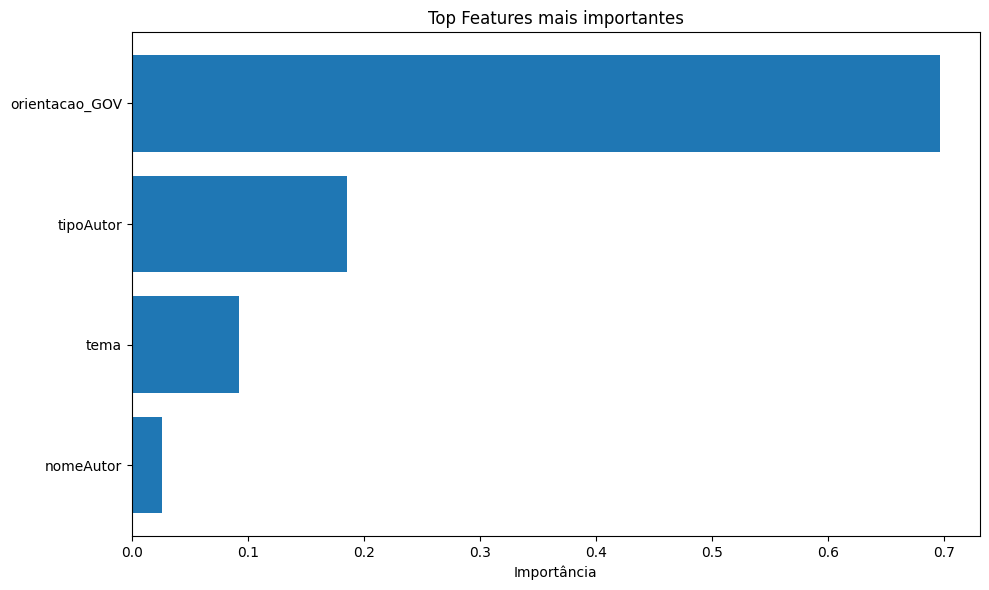

In [35]:
import matplotlib.pyplot as plt

# Gráfico de barras
plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'][:20], feat_imp['Importance'][:20])
plt.gca().invert_yaxis()
plt.title('Top Features mais importantes')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()


# Feature Engineering com Métricas de Comunidade

## Preparação dos Datasets

In [36]:
votacoes_autor

,id,data,idOrgao,siglaOrgao,aprovacao,votosSim,votosNao,votosOutros,descricao,ano,proposicao_id,proposicao_ementa,id_proposicao,tema,orientacao_GOV,tipoAutor,idDeputadoAutor,nomeAutor
0,100481-37,2003-11-19,180,PLEN,0.0,0,0,0,Rejeitada a Proposta da Comissão para que a vo...,2003,100481,"Altera o art. 149 do Decreto-Lei nº 2.848, de ...",100481.0,Direito Penal e Processual Penal,Neutro,Órgão do Poder Legislativo,NaN,SENADO FEDERAL - WALDECK ORNELAS
1,100481-39,2003-11-19,180,PLEN,1.0,0,0,0,"Aprovado o Projeto de Lei nº 7.429, de 2002.",2003,100481,"Altera o art. 149 do Decreto-Lei nº 2.848, de ...",100481.0,Direito Penal e Processual Penal,Neutro,Órgão do Poder Legislativo,NaN,SENADO FEDERAL - WALDECK ORNELAS
2,100481-41,2003-11-19,180,PLEN,1.0,0,0,0,Aprovada a Redação Final oferecida pelo Relato...,2003,100481,"Altera o art. 149 do Decreto-Lei nº 2.848, de ...",100481.0,Direito Penal e Processual Penal,Neutro,Órgão do Poder Legislativo,NaN,SENADO FEDERAL - WALDECK ORNELAS
3,1006391-32,2024-02-20,180,PLEN,1.0,0,0,0,Aprovado requerimento n. 1884/2023 do Sr. Fábi...,2024,1006391,"Dispõe sobre a obrigatoriedade de divulgação, ...",1006391.0,Saúde,Neutro,Deputado(a),178848.0,Conceição Sampaio
4,100719-54,2012-10-31,180,PLEN,1.0,0,0,0,Aprovada a Emenda adotada pela Comissão de Ciê...,2012,100719,"Altera os arts. 2º e 17 da Lei nº 10.098, de 1...",100719.0,Direitos Humanos e Minorias,Neutro,COMISSÃO PERMANENTE,NaN,Comissão de Legislação Participativa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105539,996935-50,2015-08-20,180,PLEN,1.0,0,0,0,Aprovada a Redação Final assinada pelo Relator...,2015,996935,Estabelece diretrizes para a celebração de con...,996935.0,Economia,Neutro,Deputado(a),143632.0,Domingos Neto
105540,99834-38,2005-07-07,180,PLEN,1.0,0,0,0,Aprovado o Substitutivo adotado pela Comissão ...,2005,99834,Aprova o texto do Acordo sobre Cooperação na Á...,99834.0,"Energia, Recursos Hídricos e Minerais",Neutro,COMISSÃO PERMANENTE,NaN,Comissão de Relações Exteriores e de Defesa Na...
105541,99834-42,2005-07-07,180,PLEN,1.0,0,0,0,"Aprovada a Redação Final, assinada pelo Dep. M...",2005,99834,Aprova o texto do Acordo sobre Cooperação na Á...,99834.0,"Energia, Recursos Hídricos e Minerais",Neutro,COMISSÃO PERMANENTE,NaN,Comissão de Relações Exteriores e de Defesa Na...
105542,99835-43,2006-03-21,180,PLEN,1.0,0,0,0,Aprovado requerimento do TRIBUNAL SUPERIOR DO ...,2006,99835,Dispõe sobre a criação de funções comissionada...,99835.0,Administração Pública,Neutro,Órgão do Poder Judiciário,NaN,TRIBUNAL SUPERIOR DO TRABALHO


In [37]:
votacoes_data_ref = votacoes_autor.copy()

# 1. Converte a coluna 'data' para datetime (caso ainda não esteja)
votacoes_data_ref['data'] = pd.to_datetime(votacoes_data_ref['data'])

# 2. Extrai as datas únicas em ordem crescente
datas_ordenadas = sorted(votacoes_data_ref['data'].unique())

# 3. Cria um dicionário de data para índice (começando do 1)
mapa_data_ref = {data: i+1 for i, data in enumerate(datas_ordenadas)}

# 4. Cria a nova coluna 'data_ref' com base no mapeamento
votacoes_data_ref['data_ref'] = votacoes_data_ref['data'].map(mapa_data_ref)

votacoes_data_ref = votacoes_data_ref.sort_values(by='data_ref').reset_index(drop=True)


votacoes_data_ref

,id,data,idOrgao,siglaOrgao,aprovacao,votosSim,votosNao,votosOutros,descricao,ano,proposicao_id,proposicao_ementa,id_proposicao,tema,orientacao_GOV,tipoAutor,idDeputadoAutor,nomeAutor,data_ref
0,103255-3,2003-02-19,180,PLEN,1.0,0,0,0,Aprovado o Requerimento,2003,102277,Disciplina as relações jurídicas decorrentes d...,102277.0,Administração Pública,Neutro,Deputado(a),74218.0,Walter Pinheiro,1
1,102277-6,2003-02-19,180,PLEN,1.0,0,0,0,Aprovado requerimento n. 264/2002 de Líderes q...,2003,102277,Disciplina as relações jurídicas decorrentes d...,102277.0,Administração Pública,Neutro,Deputado(a),74218.0,Walter Pinheiro,1
2,98922-25,2003-02-19,180,PLEN,1.0,0,0,0,"Aprovado, em apreciação preliminar, o Parecer ...",2003,98922,Autoriza o Poder Executivo a doar à República ...,98922.0,Relações Internacionais e Comércio Exterior,Neutro,Órgão do Poder Executivo,NaN,Poder Executivo,1
3,98922-29,2003-02-19,180,PLEN,1.0,0,0,0,Aprovada a Redação Final oferecida pelo Relato...,2003,98922,Autoriza o Poder Executivo a doar à República ...,98922.0,Relações Internacionais e Comércio Exterior,Neutro,Órgão do Poder Executivo,NaN,Poder Executivo,1
4,96076-49,2003-02-19,180,PLEN,1.0,0,0,0,Aprovada a Redação Final oferecida pelo Relato...,2003,96076,Dispõe sobre o Estatuto de Defesa do Torcedor ...,96076.0,Esporte e Lazer,Neutro,Órgão do Poder Executivo,NaN,Poder Executivo,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105539,347421-202,2024-12-19,180,PLEN,NaN,4,360,1,Suprimido o texto. Sim: 4; Não: 360; Total: 364.,2024,347421,"Altera o Sistema Tributário Nacional, unifica ...",347421.0,Finanças Públicas e Orçamento,Não,Deputado(a),73778.0,Luiz Carlos Hauly,1889
105540,347421-202,2024-12-19,180,PLEN,NaN,4,360,1,Suprimido o texto. Sim: 4; Não: 360; Total: 364.,2024,347421,"Altera o Sistema Tributário Nacional, unifica ...",347421.0,Finanças Públicas e Orçamento,Não,Deputado(a),74283.0,Vicentinho,1889
105541,347421-202,2024-12-19,180,PLEN,NaN,4,360,1,Suprimido o texto. Sim: 4; Não: 360; Total: 364.,2024,347421,"Altera o Sistema Tributário Nacional, unifica ...",347421.0,Finanças Públicas e Orçamento,Não,Deputado(a),141531.0,Rodrigo de Castro,1889
105542,347421-205,2024-12-19,180,PLEN,NaN,349,143,1,Mantido o texto. Sim: 349; Não: 143; Abstenção...,2024,347421,"Altera o Sistema Tributário Nacional, unifica ...",347421.0,Finanças Públicas e Orçamento,Sim,Deputado(a),74063.0,Fernando de Fabinho,1889


In [38]:
legislaturas

,idLegislatura,uri,dataInicio,dataFim,anoEleicao
0,57,https://dadosabertos.camara.leg.br/api/v2/legi...,2023-02-01,2027-01-31,2022
1,56,https://dadosabertos.camara.leg.br/api/v2/legi...,2019-02-01,2023-01-31,2018
2,55,https://dadosabertos.camara.leg.br/api/v2/legi...,2015-02-01,2019-01-31,2014
3,54,https://dadosabertos.camara.leg.br/api/v2/legi...,2011-02-01,2015-01-31,2010
4,53,https://dadosabertos.camara.leg.br/api/v2/legi...,2007-02-01,2011-01-31,2006
5,52,https://dadosabertos.camara.leg.br/api/v2/legi...,2003-02-01,2007-01-31,2002
6,51,https://dadosabertos.camara.leg.br/api/v2/legi...,1999-02-01,2003-01-31,1998
7,50,https://dadosabertos.camara.leg.br/api/v2/legi...,1995-02-01,1999-01-31,1994
8,49,https://dadosabertos.camara.leg.br/api/v2/legi...,1991-02-01,1995-01-31,1990
9,48,https://dadosabertos.camara.leg.br/api/v2/legi...,1987-02-01,1991-01-31,1986


In [39]:
votacoes_leg = votacoes_data_ref.copy()

# 1. Garante que todas as colunas de data estejam no formato datetime
votacoes_leg['data'] = pd.to_datetime(votacoes_leg['data'])
legislaturas['dataInicio'] = pd.to_datetime(legislaturas['dataInicio'])
legislaturas['dataFim'] = pd.to_datetime(legislaturas['dataFim'])

# 2. Função para buscar a legislatura com base na data
def buscar_legislatura(data_votacao):
    for _, row in legislaturas.iterrows():
        if row['dataInicio'] <= data_votacao <= row['dataFim']:
            return row['idLegislatura']
    return None  # caso não encontre (opcional: preencher com -1)

# 3. Aplica a função para cada linha
votacoes_leg['legislatura'] = votacoes_leg['data'].apply(buscar_legislatura)

votacoes_leg


,id,data,idOrgao,siglaOrgao,aprovacao,votosSim,votosNao,votosOutros,descricao,ano,proposicao_id,proposicao_ementa,id_proposicao,tema,orientacao_GOV,tipoAutor,idDeputadoAutor,nomeAutor,data_ref,legislatura
0,103255-3,2003-02-19,180,PLEN,1.0,0,0,0,Aprovado o Requerimento,2003,102277,Disciplina as relações jurídicas decorrentes d...,102277.0,Administração Pública,Neutro,Deputado(a),74218.0,Walter Pinheiro,1,52
1,102277-6,2003-02-19,180,PLEN,1.0,0,0,0,Aprovado requerimento n. 264/2002 de Líderes q...,2003,102277,Disciplina as relações jurídicas decorrentes d...,102277.0,Administração Pública,Neutro,Deputado(a),74218.0,Walter Pinheiro,1,52
2,98922-25,2003-02-19,180,PLEN,1.0,0,0,0,"Aprovado, em apreciação preliminar, o Parecer ...",2003,98922,Autoriza o Poder Executivo a doar à República ...,98922.0,Relações Internacionais e Comércio Exterior,Neutro,Órgão do Poder Executivo,NaN,Poder Executivo,1,52
3,98922-29,2003-02-19,180,PLEN,1.0,0,0,0,Aprovada a Redação Final oferecida pelo Relato...,2003,98922,Autoriza o Poder Executivo a doar à República ...,98922.0,Relações Internacionais e Comércio Exterior,Neutro,Órgão do Poder Executivo,NaN,Poder Executivo,1,52
4,96076-49,2003-02-19,180,PLEN,1.0,0,0,0,Aprovada a Redação Final oferecida pelo Relato...,2003,96076,Dispõe sobre o Estatuto de Defesa do Torcedor ...,96076.0,Esporte e Lazer,Neutro,Órgão do Poder Executivo,NaN,Poder Executivo,1,52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105539,347421-202,2024-12-19,180,PLEN,NaN,4,360,1,Suprimido o texto. Sim: 4; Não: 360; Total: 364.,2024,347421,"Altera o Sistema Tributário Nacional, unifica ...",347421.0,Finanças Públicas e Orçamento,Não,Deputado(a),73778.0,Luiz Carlos Hauly,1889,57
105540,347421-202,2024-12-19,180,PLEN,NaN,4,360,1,Suprimido o texto. Sim: 4; Não: 360; Total: 364.,2024,347421,"Altera o Sistema Tributário Nacional, unifica ...",347421.0,Finanças Públicas e Orçamento,Não,Deputado(a),74283.0,Vicentinho,1889,57
105541,347421-202,2024-12-19,180,PLEN,NaN,4,360,1,Suprimido o texto. Sim: 4; Não: 360; Total: 364.,2024,347421,"Altera o Sistema Tributário Nacional, unifica ...",347421.0,Finanças Públicas e Orçamento,Não,Deputado(a),141531.0,Rodrigo de Castro,1889,57
105542,347421-205,2024-12-19,180,PLEN,NaN,349,143,1,Mantido o texto. Sim: 349; Não: 143; Abstenção...,2024,347421,"Altera o Sistema Tributário Nacional, unifica ...",347421.0,Finanças Públicas e Orçamento,Sim,Deputado(a),74063.0,Fernando de Fabinho,1889,57


In [40]:
votacoes_leg = votacoes_leg[votacoes_leg['idDeputadoAutor'].notna()]

votacoes_leg

,id,data,idOrgao,siglaOrgao,aprovacao,votosSim,votosNao,votosOutros,descricao,ano,proposicao_id,proposicao_ementa,id_proposicao,tema,orientacao_GOV,tipoAutor,idDeputadoAutor,nomeAutor,data_ref,legislatura
0,103255-3,2003-02-19,180,PLEN,1.0,0,0,0,Aprovado o Requerimento,2003,102277,Disciplina as relações jurídicas decorrentes d...,102277.0,Administração Pública,Neutro,Deputado(a),74218.0,Walter Pinheiro,1,52
1,102277-6,2003-02-19,180,PLEN,1.0,0,0,0,Aprovado requerimento n. 264/2002 de Líderes q...,2003,102277,Disciplina as relações jurídicas decorrentes d...,102277.0,Administração Pública,Neutro,Deputado(a),74218.0,Walter Pinheiro,1,52
59,105029-15,2003-03-18,180,PLEN,1.0,0,0,0,Aprovado REQ 450/2003 do Sr. Maurício Rabelo q...,2003,105029,"Institui o ano de 2006 como o "" Ano da Mulher""...",105029.0,Direitos Humanos e Minorias,Neutro,Deputado(a),73947.0,Maurício Rabelo,8,52
72,107184-2,2003-03-18,180,PLEN,1.0,0,0,0,Aprovado o Requerimento,2003,105029,"Institui o ano de 2006 como o "" Ano da Mulher""...",105029.0,Direitos Humanos e Minorias,Neutro,Deputado(a),73947.0,Maurício Rabelo,8,52
81,19701-51,2003-03-20,180,PLEN,1.0,0,0,0,"Aprovado o Projeto de Lei nº 3.462, de 2000, r...",2003,19701,Anistia os trabalhadores da Empresa Brasileira...,19701.0,Trabalho e Emprego,Neutro,Deputado(a),74082.0,Paulo Rocha,10,52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105539,347421-202,2024-12-19,180,PLEN,NaN,4,360,1,Suprimido o texto. Sim: 4; Não: 360; Total: 364.,2024,347421,"Altera o Sistema Tributário Nacional, unifica ...",347421.0,Finanças Públicas e Orçamento,Não,Deputado(a),73778.0,Luiz Carlos Hauly,1889,57
105540,347421-202,2024-12-19,180,PLEN,NaN,4,360,1,Suprimido o texto. Sim: 4; Não: 360; Total: 364.,2024,347421,"Altera o Sistema Tributário Nacional, unifica ...",347421.0,Finanças Públicas e Orçamento,Não,Deputado(a),74283.0,Vicentinho,1889,57
105541,347421-202,2024-12-19,180,PLEN,NaN,4,360,1,Suprimido o texto. Sim: 4; Não: 360; Total: 364.,2024,347421,"Altera o Sistema Tributário Nacional, unifica ...",347421.0,Finanças Públicas e Orçamento,Não,Deputado(a),141531.0,Rodrigo de Castro,1889,57
105542,347421-205,2024-12-19,180,PLEN,NaN,349,143,1,Mantido o texto. Sim: 349; Não: 143; Abstenção...,2024,347421,"Altera o Sistema Tributário Nacional, unifica ...",347421.0,Finanças Públicas e Orçamento,Sim,Deputado(a),74063.0,Fernando de Fabinho,1889,57


In [41]:
votacoes_leg.columns

Index(['id', 'data', 'idOrgao', 'siglaOrgao', 'aprovacao', 'votosSim',
       'votosNao', 'votosOutros', 'descricao', 'ano', 'proposicao_id',
       'proposicao_ementa', 'id_proposicao', 'tema', 'orientacao_GOV',
       'tipoAutor', 'idDeputadoAutor', 'nomeAutor', 'data_ref', 'legislatura'],
      dtype='object')

In [42]:
votacoes_leg.to_csv('votacoes_full.csv', index=False, encoding='utf-8')

In [43]:
deputados.columns

Index(['uri', 'nome', 'idLegislaturaInicial', 'idLegislaturaFinal',
       'nomeCivil', 'cpf', 'siglaSexo', 'urlRedeSocial', 'urlWebsite',
       'dataNascimento', 'dataFalecimento', 'ufNascimento',
       'municipioNascimento'],
      dtype='object')

In [44]:
votos.columns

Index(['idVotacao', 'uriVotacao', 'dataHoraVoto', 'voto', 'deputado_id',
       'deputado_uri', 'deputado_nome', 'deputado_siglaPartido',
       'deputado_uriPartido', 'deputado_siglaUf', 'deputado_idLegislatura',
       'deputado_urlFoto', 'ano'],
      dtype='object')

In [45]:
# Extrai o ID do deputado da URL
deputados_id = deputados.copy()

# Garante que deputados_id['id'] está no tipo int (vindo do final da URL)
deputados_id['id'] = deputados_id['uri'].str.extract(r'/deputados/(\d+)').astype(int)

# Cria dicionário: legislatura → conjunto de ids dos deputados que atuaram naquela legislatura
deputados_por_legislatura = {}

for _, row in deputados_id.iterrows():
    for leg in range(row['idLegislaturaInicial'], row['idLegislaturaFinal'] + 1):
        deputados_por_legislatura.setdefault(leg, set()).add(row['id'])

deputados_por_legislatura

{57: {62881,
  66385,
  66828,
  68720,
  69871,
  72442,
  73433,
  73441,
  73486,
  73531,
  73579,
  73604,
  73692,
  73701,
  73768,
  73778,
  73788,
  73801,
  73806,
  73808,
  74041,
  74043,
  74044,
  74052,
  74057,
  74060,
  74075,
  74079,
  74084,
  74090,
  74095,
  74141,
  74156,
  74158,
  74159,
  74160,
  74161,
  74171,
  74253,
  74262,
  74270,
  74273,
  74283,
  74299,
  74317,
  74356,
  74371,
  74374,
  74376,
  74383,
  74398,
  74400,
  74428,
  74454,
  74467,
  74478,
  74537,
  74550,
  74554,
  74574,
  74585,
  74646,
  74696,
  74784,
  74848,
  74856,
  74858,
  80815,
  81055,
  88256,
  89536,
  91228,
  92102,
  92346,
  92699,
  92776,
  98057,
  98148,
  98615,
  100689,
  103758,
  104552,
  107283,
  107970,
  109429,
  115200,
  116379,
  121948,
  122158,
  122195,
  122974,
  123086,
  123756,
  128760,
  132504,
  133439,
  133810,
  136811,
  137070,
  138286,
  139285,
  141391,
  141398,
  141408,
  141411,
  141421,
  141431,
  141

In [46]:
votos

,idVotacao,uriVotacao,dataHoraVoto,voto,deputado_id,deputado_uri,deputado_nome,deputado_siglaPartido,deputado_uriPartido,deputado_siglaUf,deputado_idLegislatura,deputado_urlFoto,ano
0,37897-3,https://dadosabertos.camara.leg.br/api/v2/vota...,2001-12-11T19:49:15,Sim,73886.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Adão Pretto,PT,https://dadosabertos.camara.leg.br/api/v2/part...,RS,51,https://www.camara.leg.br/internet/deputado/ba...,2001
1,37897-3,https://dadosabertos.camara.leg.br/api/v2/vota...,2001-12-11T19:29:35,Sim,74328.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Adauto Pereira,PFL,https://dadosabertos.camara.leg.br/api/v2/part...,PB,51,https://www.camara.leg.br/internet/deputado/ba...,2001
2,37897-3,https://dadosabertos.camara.leg.br/api/v2/vota...,2001-12-11T19:26:34,Sim,74450.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Adolfo Marinho,PSDB,https://dadosabertos.camara.leg.br/api/v2/part...,CE,51,https://www.camara.leg.br/internet/deputado/ba...,2001
3,37897-3,https://dadosabertos.camara.leg.br/api/v2/vota...,2001-12-11T19:25:14,Artigo 17,74646.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Aécio Neves,PSDB,https://dadosabertos.camara.leg.br/api/v2/part...,MG,51,https://www.camara.leg.br/internet/deputado/ba...,2001
4,37897-3,https://dadosabertos.camara.leg.br/api/v2/vota...,2001-12-11T19:26:59,Sim,73765.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Affonso Camargo,PFL,https://dadosabertos.camara.leg.br/api/v2/part...,PR,51,https://www.camara.leg.br/internet/deputado/ba...,2001
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1698924,945492-151,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-11T13:16:40,Sim,178946.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Soraya Santos,PL,https://dadosabertos.camara.leg.br/api/v2/part...,RJ,57,https://www.camara.leg.br/internet/deputado/ba...,2024
1698925,945492-151,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-11T13:16:40,Sim,178934.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Toninho Wandscheer,PP,https://dadosabertos.camara.leg.br/api/v2/part...,PR,57,https://www.camara.leg.br/internet/deputado/ba...,2024
1698926,945492-151,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-11T13:16:40,Sim,91228.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Waldemar Oliveira,AVANTE,https://dadosabertos.camara.leg.br/api/v2/part...,PE,57,https://www.camara.leg.br/internet/deputado/ba...,2024
1698927,945492-151,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-11T13:16:40,Sim,224333.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Welter,PT,https://dadosabertos.camara.leg.br/api/v2/part...,PR,57,https://www.camara.leg.br/internet/deputado/ba...,2024


In [47]:
votos_ref = votos.copy()

# Corrige a coluna para datetime
votos_ref['dataHoraVoto'] = pd.to_datetime(votos_ref['dataHoraVoto'], errors='coerce')

# Extrai apenas a data (sem hora) para facilitar merge com votacoes_leg
votos_ref['data'] = votos_ref['dataHoraVoto'].dt.date
votos_ref['data'] = pd.to_datetime(votos_ref['data'])

votos_ref

,idVotacao,uriVotacao,dataHoraVoto,voto,deputado_id,deputado_uri,deputado_nome,deputado_siglaPartido,deputado_uriPartido,deputado_siglaUf,deputado_idLegislatura,deputado_urlFoto,ano,data
0,37897-3,https://dadosabertos.camara.leg.br/api/v2/vota...,2001-12-11 19:49:15,Sim,73886.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Adão Pretto,PT,https://dadosabertos.camara.leg.br/api/v2/part...,RS,51,https://www.camara.leg.br/internet/deputado/ba...,2001,2001-12-11
1,37897-3,https://dadosabertos.camara.leg.br/api/v2/vota...,2001-12-11 19:29:35,Sim,74328.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Adauto Pereira,PFL,https://dadosabertos.camara.leg.br/api/v2/part...,PB,51,https://www.camara.leg.br/internet/deputado/ba...,2001,2001-12-11
2,37897-3,https://dadosabertos.camara.leg.br/api/v2/vota...,2001-12-11 19:26:34,Sim,74450.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Adolfo Marinho,PSDB,https://dadosabertos.camara.leg.br/api/v2/part...,CE,51,https://www.camara.leg.br/internet/deputado/ba...,2001,2001-12-11
3,37897-3,https://dadosabertos.camara.leg.br/api/v2/vota...,2001-12-11 19:25:14,Artigo 17,74646.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Aécio Neves,PSDB,https://dadosabertos.camara.leg.br/api/v2/part...,MG,51,https://www.camara.leg.br/internet/deputado/ba...,2001,2001-12-11
4,37897-3,https://dadosabertos.camara.leg.br/api/v2/vota...,2001-12-11 19:26:59,Sim,73765.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Affonso Camargo,PFL,https://dadosabertos.camara.leg.br/api/v2/part...,PR,51,https://www.camara.leg.br/internet/deputado/ba...,2001,2001-12-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1698924,945492-151,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-11 13:16:40,Sim,178946.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Soraya Santos,PL,https://dadosabertos.camara.leg.br/api/v2/part...,RJ,57,https://www.camara.leg.br/internet/deputado/ba...,2024,2024-12-11
1698925,945492-151,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-11 13:16:40,Sim,178934.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Toninho Wandscheer,PP,https://dadosabertos.camara.leg.br/api/v2/part...,PR,57,https://www.camara.leg.br/internet/deputado/ba...,2024,2024-12-11
1698926,945492-151,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-11 13:16:40,Sim,91228.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Waldemar Oliveira,AVANTE,https://dadosabertos.camara.leg.br/api/v2/part...,PE,57,https://www.camara.leg.br/internet/deputado/ba...,2024,2024-12-11
1698927,945492-151,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-11 13:16:40,Sim,224333.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Welter,PT,https://dadosabertos.camara.leg.br/api/v2/part...,PR,57,https://www.camara.leg.br/internet/deputado/ba...,2024,2024-12-11


In [48]:
# Cria um DataFrame auxiliar com datas únicas e seus respectivos data_ref
datas_ref_map = votacoes_leg[['data', 'data_ref']].drop_duplicates()

# Faz o merge com votos_ref para adicionar data_ref
votos_ref = votos_ref.merge(datas_ref_map, on='data', how='left')

# Filtra apenas os votos com data_ref válido
votos_ref = votos_ref[votos_ref['data_ref'].notna()]
votos_ref['data_ref'] = votos_ref['data_ref'].astype(int)
votos_ref

,idVotacao,uriVotacao,dataHoraVoto,voto,deputado_id,deputado_uri,deputado_nome,deputado_siglaPartido,deputado_uriPartido,deputado_siglaUf,deputado_idLegislatura,deputado_urlFoto,ano,data,data_ref
2681,104509-28,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-11-18 16:25:57,Não,73928.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Ann Pontes,PMDB,https://dadosabertos.camara.leg.br/api/v2/part...,PA,52,https://www.camara.leg.br/internet/deputado/ba...,2003,2003-11-18,97
2682,104509-28,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-11-18 16:25:57,Não,73434.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Arnaldo Faria de Sá,PTB,https://dadosabertos.camara.leg.br/api/v2/part...,SP,52,https://www.camara.leg.br/internet/deputado/ba...,2003,2003-11-18,97
2683,104509-28,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-11-18 16:25:57,Sim,74263.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Cláudio Magrão,PPS,https://dadosabertos.camara.leg.br/api/v2/part...,SP,52,https://www.camara.leg.br/internet/deputado/ba...,2003,2003-11-18,97
2684,104509-28,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-11-18 16:25:57,Sim,74060.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Daniel Almeida,PCdoB,https://dadosabertos.camara.leg.br/api/v2/part...,BA,52,https://www.camara.leg.br/internet/deputado/ba...,2003,2003-11-18,97
2685,104509-28,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-11-18 16:25:57,Sim,74381.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Dra. Clair,PT,https://dadosabertos.camara.leg.br/api/v2/part...,PR,52,https://www.camara.leg.br/internet/deputado/ba...,2003,2003-11-18,97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1698924,945492-151,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-11 13:16:40,Sim,178946.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Soraya Santos,PL,https://dadosabertos.camara.leg.br/api/v2/part...,RJ,57,https://www.camara.leg.br/internet/deputado/ba...,2024,2024-12-11,1884
1698925,945492-151,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-11 13:16:40,Sim,178934.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Toninho Wandscheer,PP,https://dadosabertos.camara.leg.br/api/v2/part...,PR,57,https://www.camara.leg.br/internet/deputado/ba...,2024,2024-12-11,1884
1698926,945492-151,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-11 13:16:40,Sim,91228.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Waldemar Oliveira,AVANTE,https://dadosabertos.camara.leg.br/api/v2/part...,PE,57,https://www.camara.leg.br/internet/deputado/ba...,2024,2024-12-11,1884
1698927,945492-151,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-11 13:16:40,Sim,224333.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Welter,PT,https://dadosabertos.camara.leg.br/api/v2/part...,PR,57,https://www.camara.leg.br/internet/deputado/ba...,2024,2024-12-11,1884


In [49]:
votos_ref = votos_ref.sort_values(by='data_ref').reset_index(drop=True)

votos_ref

,idVotacao,uriVotacao,dataHoraVoto,voto,deputado_id,deputado_uri,deputado_nome,deputado_siglaPartido,deputado_uriPartido,deputado_siglaUf,deputado_idLegislatura,deputado_urlFoto,ano,data,data_ref
0,14312-65,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-04-02 19:19:48,Sim,74072.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Anivaldo Vale,PSDB,https://dadosabertos.camara.leg.br/api/v2/part...,PA,52,https://www.camara.leg.br/internet/deputado/ba...,2003,2003-04-02,15
1,14312-65,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-04-02 19:20:12,Sim,74810.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Luiz Bittencourt,PMDB,https://dadosabertos.camara.leg.br/api/v2/part...,GO,52,https://www.camara.leg.br/internet/deputado/ba...,2003,2003-04-02,15
2,14312-65,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-04-02 19:19:51,Sim,74059.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Luiz Bassuma,PT,https://dadosabertos.camara.leg.br/api/v2/part...,BA,52,https://www.camara.leg.br/internet/deputado/ba...,2003,2003-04-02,15
3,14312-65,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-04-02 19:19:48,Sim,74133.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Luiz Alberto,PT,https://dadosabertos.camara.leg.br/api/v2/part...,BA,52,https://www.camara.leg.br/internet/deputado/ba...,2003,2003-04-02,15
4,14312-65,https://dadosabertos.camara.leg.br/api/v2/vota...,2003-04-02 19:20:07,Sim,73483.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Luis Carlos Heinze,PPB,https://dadosabertos.camara.leg.br/api/v2/part...,RS,52,https://www.camara.leg.br/internet/deputado/ba...,2003,2003-04-02,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1012331,347421-200,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-19 14:21:59,Não,160642.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Pastor Eurico,PL,https://dadosabertos.camara.leg.br/api/v2/part...,PE,57,https://www.camara.leg.br/internet/deputado/ba...,2024,2024-12-19,1889
1012332,347421-200,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-19 14:22:06,Não,180214.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Pastor Diniz,UNIÃO,https://dadosabertos.camara.leg.br/api/v2/part...,RR,57,https://www.camara.leg.br/internet/deputado/ba...,2024,2024-12-19,1889
1012333,347421-200,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-19 14:20:40,Sim,160556.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Padre João,PT,https://dadosabertos.camara.leg.br/api/v2/part...,MG,57,https://www.camara.leg.br/internet/deputado/ba...,2024,2024-12-19,1889
1012334,347421-200,https://dadosabertos.camara.leg.br/api/v2/vota...,2024-12-19 14:22:11,Sim,220627.0,https://dadosabertos.camara.leg.br/api/v2/depu...,Paulinho Freire,UNIÃO,https://dadosabertos.camara.leg.br/api/v2/part...,RN,57,https://www.camara.leg.br/internet/deputado/ba...,2024,2024-12-19,1889


## Detecção das Comunidades